In [1]:
from utils.dependencies import *;
import ComputeMultiplicity as cm

/home/bepennell/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [ ]:
def adjustment(fb, count, uprate):
    bin_count = fb*count
    single_count = (1-fb)*count

    new_fb = (bin_count*uprate) / (single_count + bin_count*uprate)
    return new_fb
    
def q_max_scaling(catalogue, bins=10):
    bin_counts = np.zeros(bins)
    bin_adjustments = np.zeros(bins)
    
    masses = catalogue["mass"]
    percs = np.percentile(masses, np.linspace(0,100,bins+1))
    for i in range(len(percs)-1):
        objs = catalogue[(masses > percs[i]) & (masses < percs[i+1])]
        print(f"{percs[i]:.3f} to {percs[i+1]:.3f}: mean q_max: {np.mean(objs['q_max'])}")
        bin_counts[i] = len(objs)
        bin_adjustments[i] = np.sum(1/objs["q_max"])/len(objs)
    return bin_counts, bin_adjustments

def extrapolate_q(likelihood_sets, bin_counts, bin_adjustments):
    fbs = np.linspace(0.02, 0.98, len(likelihood_sets[0]))
    dtheta = fbs[1] - fbs[0]
    ind_max = np.argmax(likelihood_sets, axis=1)
    second_derivative = np.array([likelihood_sets[i,ind_max[i] + 1] - 2 * likelihood_sets[i,ind_max[i]] + likelihood_sets[i,ind_max[i] - 1] for i in range(len(likelihood_sets))])/dtheta**2 
    peaks = fbs[np.argmax(likelihood_sets, axis=1)]
    sigma = 1 / np.sqrt(-second_derivative)
    
    adjusted_res = adjustment(peaks, bin_counts, bin_adjustments)
    adjusted_sigma = adjustment(peaks+sigma, bin_counts, bin_adjustments) - adjusted_res
    
    return adjusted_res, adjusted_sigma

def better_extrapolate_q(likelihood_set, bin_counts, bin_adjustments):
    fbs = np.linspace(0.02, 0.98, len(likelihood_set))
    new_fbs = np.zeros_like(likelihood_set)
    for i in range(len(likelihood_set)):
        new_fbs[i] = adjustment(fbs[i], bin_counts, bin_adjustments)

    dtheta = new_fbs[1] - new_fbs[0]
    ind_max = np.argmax(likelihood_set)
    second_derivative = (likelihood_set[ind_max + 1] - 2 * likelihood_set[ind_max] + likelihood_set[ind_max - 1])/dtheta**2
    peak = new_fbs[np.argmax(likelihood_set)]
    sigma = 1 / np.sqrt(-second_derivative)
    
    return peak, sigma

In [32]:
peak, sigma = better_extrapolate_q(new_likelihoods[5], binc[5], bina[5])

adjr10, adjs10 = extrapolate_q(np.array(new_likelihoods), *q_max_scaling(reduced_mdwarfs, bins=15))

print(peak, sigma)
print(adjr10[5], adjs10[5])

0.200 to 0.263: mean q_max: 0.3658975912717391
0.263 to 0.292: mean q_max: 0.3471651361440132
0.292 to 0.314: mean q_max: 0.33742288243130897
0.314 to 0.335: mean q_max: 0.3314429647244203
0.335 to 0.355: mean q_max: 0.32654941762297446
0.355 to 0.375: mean q_max: 0.3232483843827474
0.375 to 0.396: mean q_max: 0.31998185855091693
0.396 to 0.416: mean q_max: 0.31909883194308036
0.416 to 0.438: mean q_max: 0.3198169722135861
0.438 to 0.461: mean q_max: 0.32143783082878274
0.461 to 0.487: mean q_max: 0.3250618797818564
0.487 to 0.524: mean q_max: 0.3309671274709725
0.524 to 0.643: mean q_max: 0.35600279768004456
0.643 to 0.703: mean q_max: 0.43301066415066625
0.703 to 0.750: mean q_max: 0.4766601603843094
0.36124791423769625 0.01865486214290776
0.36124791423769625 0.011461955253528722


0.200 to 0.263: mean q_max: 0.3658975912717391
0.263 to 0.292: mean q_max: 0.3471651361440132
0.292 to 0.314: mean q_max: 0.33742288243130897
0.314 to 0.335: mean q_max: 0.3314429647244203
0.335 to 0.355: mean q_max: 0.32654941762297446
0.355 to 0.375: mean q_max: 0.3232483843827474
0.375 to 0.396: mean q_max: 0.31998185855091693
0.396 to 0.416: mean q_max: 0.31909883194308036
0.416 to 0.438: mean q_max: 0.3198169722135861
0.438 to 0.461: mean q_max: 0.32143783082878274
0.461 to 0.487: mean q_max: 0.3250618797818564
0.487 to 0.524: mean q_max: 0.3309671274709725
0.524 to 0.643: mean q_max: 0.35600279768004456
0.643 to 0.703: mean q_max: 0.43301066415066625
0.703 to 0.750: mean q_max: 0.4766601603843094


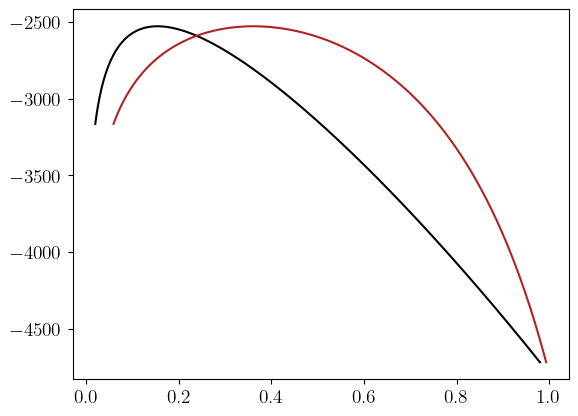

In [18]:
binc, bina = q_max_scaling(reduced_mdwarfs, bins=15)
new_fbs = better_extrapolate_q(new_likelihoods[5], binc[5], bina[5])
plt.plot(np.linspace(0.02, 0.98, len(new_likelihoods[5])), new_likelihoods[5])
plt.plot(new_fbs, new_likelihoods[5])

In [3]:
sc_cube = pickle.load(open("./data/2026-06-14-mag_scaled.pkl", "rb"))
mdwarfs = Table.read('./data/2026_06_09_final_table.fits', format='fits')
reduced_mdwarfs = mdwarfs[["solution_type", "parallax", "phot_g_mean_mag", "mass", "q_max"]]
print_table(mdwarfs)

,All,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),100.00,95.99,2.83,0.47,0.30,0.41
Counts,379264,364065,10740,1773,1127,1558


In [4]:
lowf_likelihoods = []
masses = reduced_mdwarfs["mass"]
bins = 15
percs = np.percentile(masses, np.linspace(0,100,bins+1))
for i in np.arange(bins-1, -1, -1):
    subset = reduced_mdwarfs[(reduced_mdwarfs["mass"] >= percs[i]) & (reduced_mdwarfs["mass"] < percs[i+1])]
    reduced_memory = subset[["solution_type", "phot_g_mean_mag", "parallax", "mass", "q_max"]]
    model_cube = cm.create_model_cube(grid_shape=(50,25), q_range=(0.05,0.5), p_model=(4,1.3), q_model=0)
    fbs, likelihoods_bin = cm.multiplicity(catalogue=reduced_memory, model_cube=model_cube, q_range=(0.05,0.5), sc_cube=sc_cube, resolution=1000, 
                                           cutoff=np.exp(-30), scale=3, verbose=True, combine_higher_order=True)
    lowf_likelihoods.append(likelihoods_bin)
    print(fbs[np.argmax(likelihoods_bin)])

Computing grids:   0%|          | 0/25284 [00:00<?, ?it/s]

Computing likelihoods:   0%|          | 0/1000 [00:00<?, ?it/s]

0.3457657657657658


Computing grids:   0%|          | 0/25284 [00:00<?, ?it/s]

Computing likelihoods:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Computing likelihoods:   0%|          | 0/1000 [00:00<?, ?it/s]

0.1112912912912913


Computing grids:   0%|          | 0/25285 [00:00<?, ?it/s]

Computing likelihoods:   0%|          | 0/1000 [00:00<?, ?it/s]

0.09207207207207208


In [5]:
new_likelihoods = np.flip(lowf_likelihoods, axis=0)

In [24]:
pickle.dump(new_likelihoods, open("./plot_data/2026-06-14-likelihoods.pkl", "wb"))

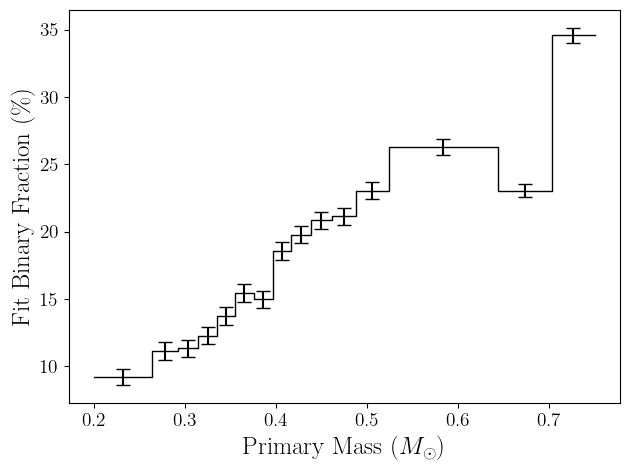

In [6]:
fbs = np.linspace(0.02, 0.98, len(lowf_likelihoods[0]))
mass_lims_b = np.clip(percs, None, 0.75)
bin_centers = (mass_lims_b[1:] + mass_lims_b[:-1]) / 2
peaks = fbs[np.argmax(new_likelihoods, axis=1)]
sigmas = np.array([cm.fisher_uncertainty(l)[0] for l in new_likelihoods])

plt.errorbar(bin_centers, peaks*100, yerr=(sigmas*100), fmt='none', capsize=5, ecolor='k', zorder=1)
plt.plot(mass_lims_b.repeat(2)[1:-1], (100*peaks).repeat(2), c="k", lw=1, zorder=1);
plt.xlabel(r"Primary Mass $(M_\odot)$");
plt.ylabel(f"Fit Binary Fraction (\%)");

plt.tight_layout();
#plt.savefig("./plots/synthbinarity.pdf", dpi=800, transparent=True)

0.200 to 0.263: mean q_max: 0.3658975912717391
0.263 to 0.292: mean q_max: 0.3471651361440132
0.292 to 0.314: mean q_max: 0.33742288243130897
0.314 to 0.335: mean q_max: 0.3314429647244203
0.335 to 0.355: mean q_max: 0.32654941762297446
0.355 to 0.375: mean q_max: 0.3232483843827474
0.375 to 0.396: mean q_max: 0.31998185855091693
0.396 to 0.416: mean q_max: 0.31909883194308036
0.416 to 0.438: mean q_max: 0.3198169722135861
0.438 to 0.461: mean q_max: 0.32143783082878274
0.461 to 0.487: mean q_max: 0.3250618797818564
0.487 to 0.524: mean q_max: 0.3309671274709725
0.524 to 0.643: mean q_max: 0.35600279768004456
0.643 to 0.703: mean q_max: 0.43301066415066625
0.703 to 0.750: mean q_max: 0.4766601603843094


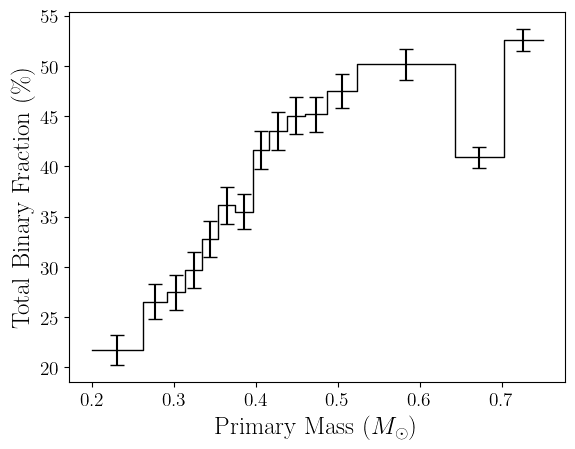

In [34]:
#adjr10, adjs10 = extrapolate_q(np.array(new_likelihoods), *q_max_scaling(reduced_mdwarfs, bins=15))
binc, bina = q_max_scaling(reduced_mdwarfs, bins=15)
adj = np.array([better_extrapolate_q(new_likelihoods[i], binc[i], bina[i]) for i in range(len(new_likelihoods))])
adjr10, adjs10 = adj[:,0], adj[:,1]
fbs = np.linspace(0.02, 0.98, len(new_likelihoods[0]))
bins = 15
percs = np.percentile(masses, np.linspace(0,100,bins+1))
mass_lims_b = np.clip(percs, None, 0.75)
bin_centers = (mass_lims_b[1:] + mass_lims_b[:-1]) / 2
peaks = adjr10
sigmas = adjs10

plt.errorbar(bin_centers, peaks*100, yerr=(sigmas*100), fmt='none', capsize=5, ecolor='k', zorder=1)
plt.plot(mass_lims_b.repeat(2)[1:-1], (100*peaks).repeat(2), c="k", lw=1, zorder=1);
plt.xlabel(r"Primary Mass $(M_\odot)$");
plt.ylabel(f"Total Binary Fraction (\%)");

0.200 to 0.263: mean q_max: 0.3658975912717391
0.263 to 0.292: mean q_max: 0.3471651361440132
0.292 to 0.314: mean q_max: 0.33742288243130897
0.314 to 0.335: mean q_max: 0.3314429647244203
0.335 to 0.355: mean q_max: 0.32654941762297446
0.355 to 0.375: mean q_max: 0.3232483843827474
0.375 to 0.396: mean q_max: 0.31998185855091693
0.396 to 0.416: mean q_max: 0.31909883194308036
0.416 to 0.438: mean q_max: 0.3198169722135861
0.438 to 0.461: mean q_max: 0.32143783082878274
0.461 to 0.487: mean q_max: 0.3250618797818564
0.487 to 0.524: mean q_max: 0.3309671274709725
0.524 to 0.643: mean q_max: 0.35600279768004456
0.643 to 0.703: mean q_max: 0.43301066415066625
0.703 to 0.750: mean q_max: 0.4766601603843094


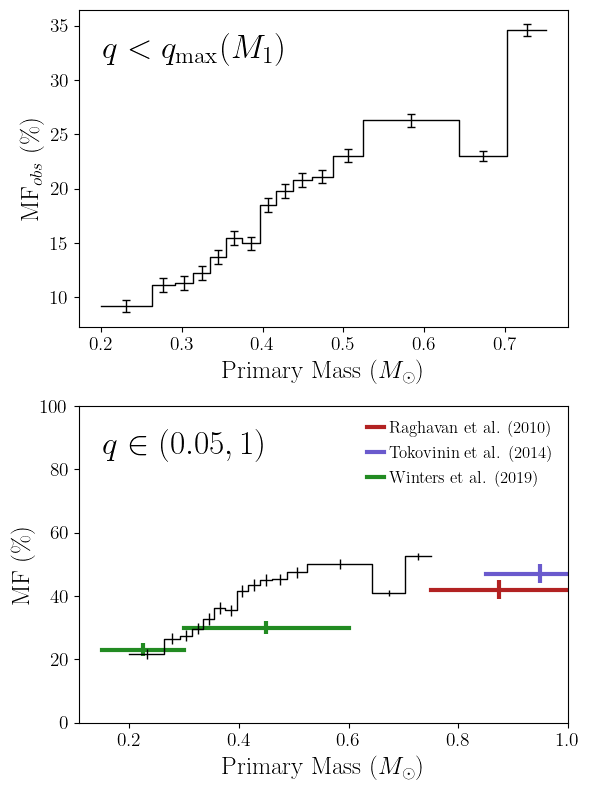

In [36]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8))

lw = 2

fbs = np.linspace(0.02, 0.98, len(new_likelihoods[0]))
mass_lims_b = np.clip(percs, None, 0.75)
bin_centers = (mass_lims_b[1:] + mass_lims_b[:-1]) / 2
peaks = fbs[np.argmax(new_likelihoods, axis=1)]
sigmas = np.array([cm.fisher_uncertainty(l)[0] for l in new_likelihoods])

ax1.errorbar(bin_centers, peaks*100, yerr=(sigmas*100), fmt='none', lw=1, capthick=1, capsize=3, ecolor='k', zorder=1)
ax1.plot(mass_lims_b.repeat(2)[1:-1], (100*peaks).repeat(2), c="k", lw=1, zorder=1);
ax1.set_xlabel(r"Primary Mass $(M_\odot)$");
ax1.set_ylabel(r"MF$_{obs}$ (\%)");
#ax1.text(0.05, 0.85, r"MF$_{obs}\%$", transform=ax1.transAxes, fontsize=24);
ax1.text(0.05, 0.85, r"$q<q_\text{max}(M_1)$", transform=ax1.transAxes, fontsize=24);

#adjr10, adjs10 = extrapolate_q(np.array(new_likelihoods), *q_max_scaling(reduced_mdwarfs, bins=15))
binc, bina = q_max_scaling(reduced_mdwarfs, bins=15)
adj = np.array([better_extrapolate_q(new_likelihoods[i], binc[i], bina[i]) for i in range(len(new_likelihoods))])
adjr10, adjs10 = adj[:,0], adj[:,1]
fbs = np.linspace(0.02, 0.98, len(new_likelihoods[0]))
bins = 15
percs = np.percentile(masses, np.linspace(0,100,bins+1))
mass_lims_b = np.clip(percs, None, 0.75)
bin_centers = (mass_lims_b[1:] + mass_lims_b[:-1]) / 2
peaks = adjr10
sigmas = adjs10

ax2.errorbar(bin_centers, peaks*100, yerr=(sigmas*100), fmt='none', ecolor='k', lw=1, zorder=1)
ax2.plot(mass_lims_b.repeat(2)[1:-1], (100*peaks).repeat(2), c="k", lw=1, zorder=1);

def cross(y, err, x, x1, x2, c, label, clw=lw+1):
    ax2.plot([x1, x2], [y, y], c=c, lw=clw, label=label, zorder=0)
    ax2.errorbar(x, y, yerr=err, fmt='none', ecolor=c, lw=clw, zorder=0)

# Raghavan
cross(42, 3, 0.875, 0.75, 1, "firebrick", "Raghavan et al. (2010)")
# Tokovinin
cross(47, 3, 0.95, 0.85, 1, "slateblue", "Tokovinin et al. (2014)")
# Winters
cross(30, 2, 0.45, 0.3, 0.6, "forestgreen", "Winters et al. (2019)")
cross(23, 2, 0.225, 0.15, 0.3, "forestgreen", None)

#ax2.text(0.05, 0.85, r"MF$\%$", transform=ax2.transAxes, fontsize=24);
ax2.text(0.05, 0.85, r"$q\in(0.05,1)$", transform=ax2.transAxes, fontsize=24);
ax2.set_xlabel(r"Primary Mass $(M_\odot)$");
ax2.set_ylabel(r"MF (\%)");

ax2.set_ylim([0,100]);
ax2.set_xlim(right=1);
ax2.legend(frameon=False, handlelength=1, fontsize=12);

plt.tight_layout()
plt.savefig("./plots/results.pdf", dpi=800, transparent=True);